In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
import os
!pip install dagshub mlflow -q
from kaggle_secrets import UserSecretsClient
os.environ["DAGSHUB_USER_TOKEN"] = UserSecretsClient().get_secret("DAGSHUB_TOKEN")

import dagshub
dagshub.init(repo_owner='lkhiz23', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)

import mlflow
print("Connected ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 91.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

Accessing as lkhiz23

Initialized MLflow to track repo "lkhiz23/IEEE-CIS-Fraud-Detection"

Repository lkhiz23/IEEE-CIS-Fraud-Detection initialized!

Connected ✓


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PATH = '/kaggle/input/competitions/ieee-fraud-detection/'

train_tx = pd.read_csv(PATH + 'train_transaction.csv')
train_id = pd.read_csv(PATH + 'train_identity.csv')
test_tx  = pd.read_csv(PATH + 'test_transaction.csv')
test_id  = pd.read_csv(PATH + 'test_identity.csv')

train = train_tx.merge(train_id, on='TransactionID', how='left')
test  = test_tx.merge(test_id,  on='TransactionID', how='left')

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
train.head()

Train shape: (590540, 434)
Test shape:  (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [19]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

print(f"Numeric features:     {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"\nCategorical columns:\n{cat_cols}")

Numeric features:     403
Categorical features: 31

Categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 0.0350 (3.50%)


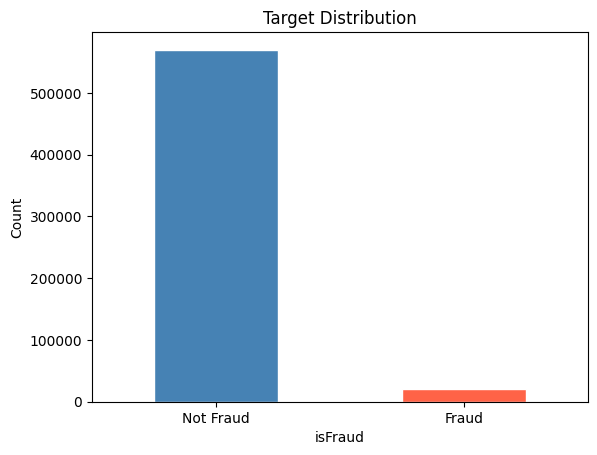

In [13]:
# Target Distribution
print(train['isFraud'].value_counts())
print(f"\nFraud rate: {train['isFraud'].mean():.4f} ({train['isFraud'].mean()*100:.2f}%)")

train['isFraud'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Target Distribution')
plt.xticks([0, 1], ['Not Fraud', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.savefig('/kaggle/working/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

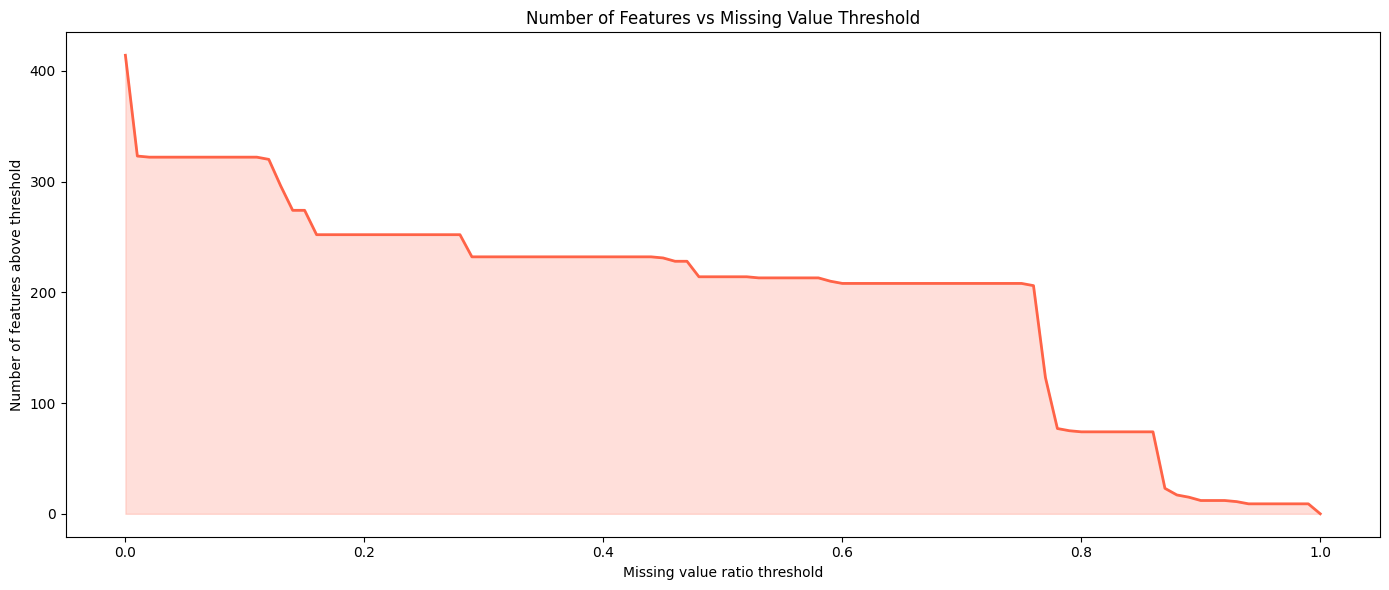


=== Missing Value Thresholds ===
Missing >  10%:  322 features
Missing >  20%:  252 features
Missing >  30%:  232 features
Missing >  40%:  232 features
Missing >  50%:  214 features
Missing >  60%:  208 features
Missing >  70%:  208 features
Missing >  80%:  74 features
Missing >  90%:  12 features
Missing > 100%:  0 features


In [12]:
missing = train.isnull().mean().sort_values(ascending=False)
missing_only = missing[missing > 0]

thresholds = np.arange(0, 1.01, 0.01)
counts = [(missing_only > t).sum() for t in thresholds]

plt.figure(figsize=(14, 6))
plt.plot(thresholds, counts, color='tomato', linewidth=2)
plt.fill_between(thresholds, counts, alpha=0.2, color='tomato')

plt.title('Number of Features vs Missing Value Threshold')
plt.xlabel('Missing value ratio threshold')
plt.ylabel('Number of features above threshold')
plt.tight_layout()
plt.savefig('/kaggle/working/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Missing Value Thresholds ===")
for threshold in np.arange(0.1, 1.1, 0.1):
    count = (missing > threshold).sum()
    print(f"Missing > {int(threshold*100):3d}%:  {count} features")

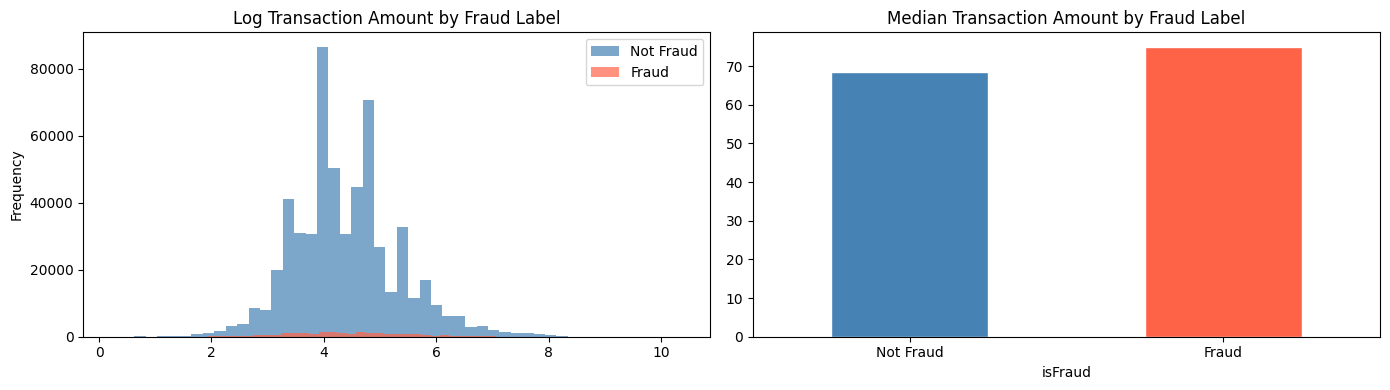

            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution by fraud label
train[train['isFraud']==0]['TransactionAmt'].apply(np.log1p).plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue', alpha=0.7, label='Not Fraud')
train[train['isFraud']==1]['TransactionAmt'].apply(np.log1p).plot(
    kind='hist', bins=50, ax=axes[0], color='tomato', alpha=0.7, label='Fraud')
axes[0].set_title('Log Transaction Amount by Fraud Label')
axes[0].legend()

# Median amount by fraud label
train.groupby('isFraud')['TransactionAmt'].median().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Median Transaction Amount by Fraud Label')
axes[1].set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/transaction_amount.png', dpi=150, bbox_inches='tight')
plt.show()

print(train.groupby('isFraud')['TransactionAmt'].describe())

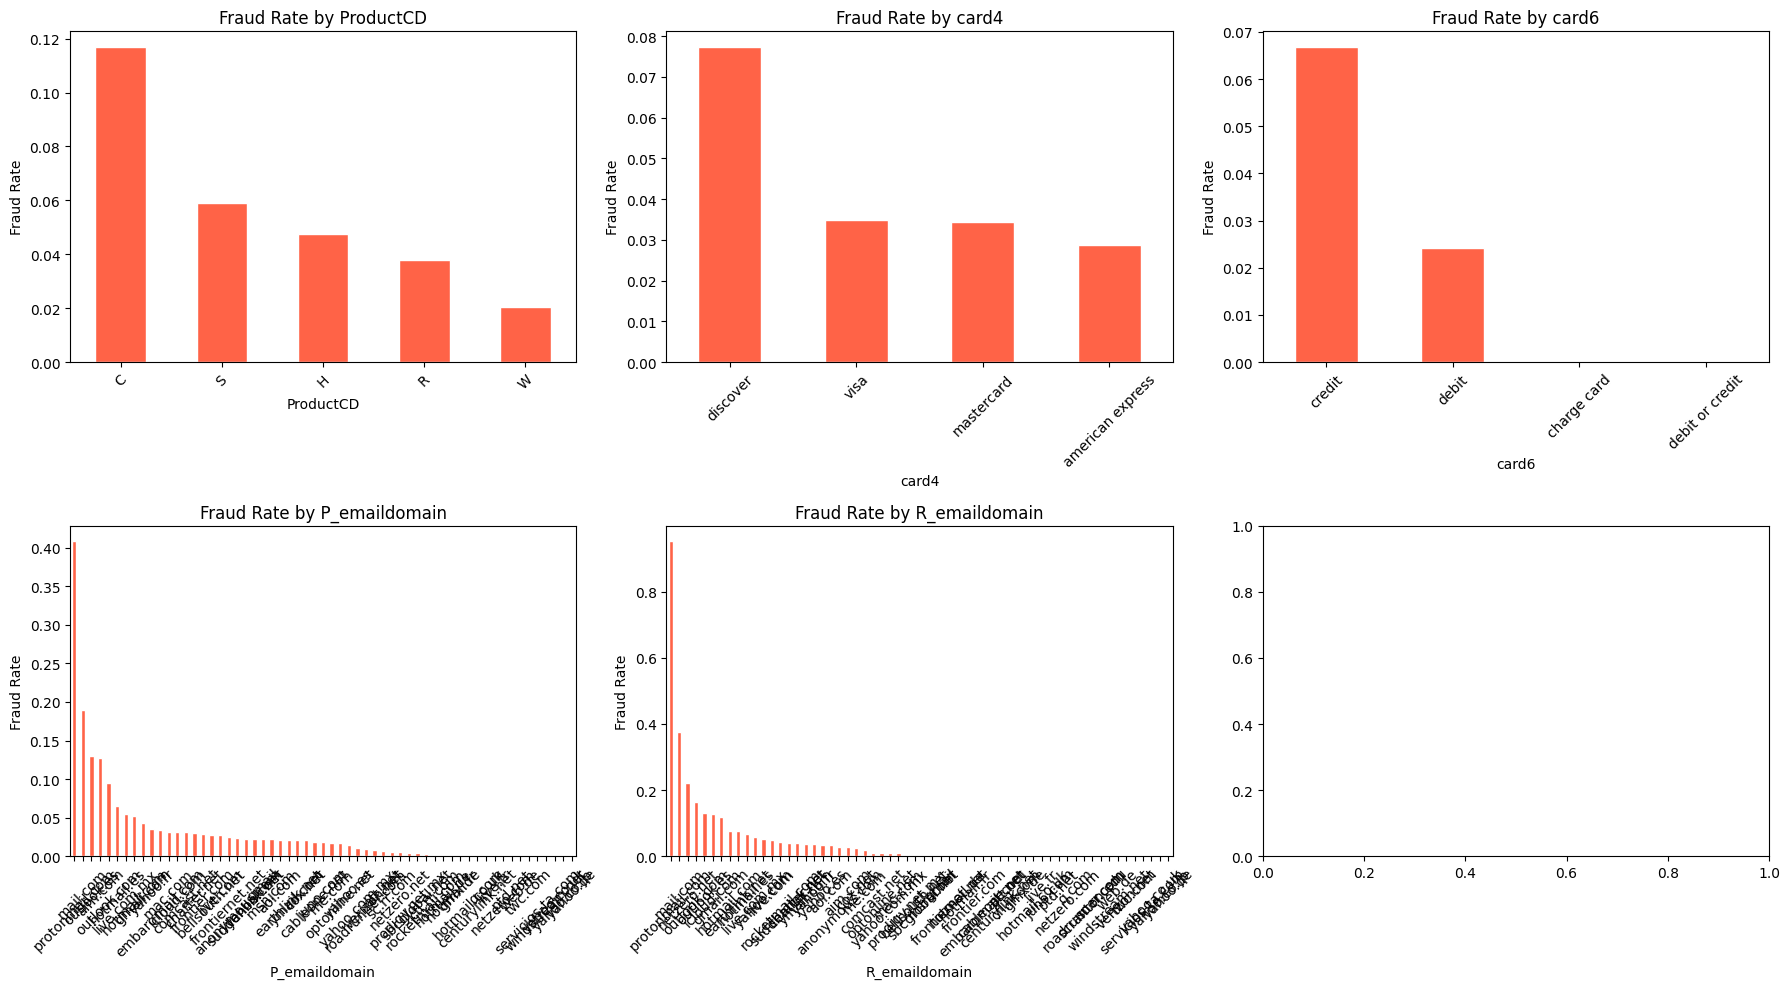

In [10]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_rate = train.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='bar', ax=axes[i], color='tomato', edgecolor='white')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/kaggle/working/categorical_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

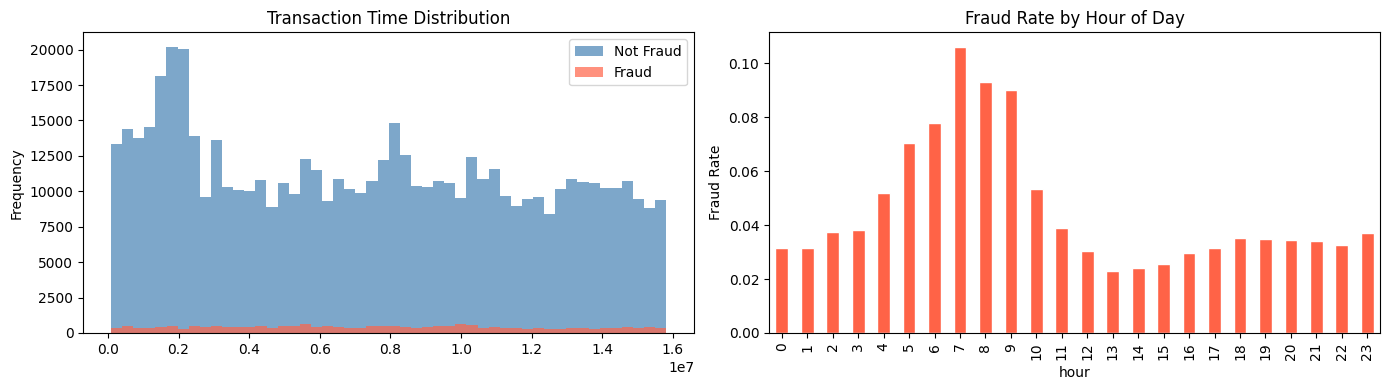

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train[train['isFraud']==0]['TransactionDT'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue', alpha=0.7, label='Not Fraud')
train[train['isFraud']==1]['TransactionDT'].plot(kind='hist', bins=50, ax=axes[0], color='tomato', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Time Distribution')
axes[0].legend()

# Hour of day extracted
train['hour'] = (train['TransactionDT'] // 3600) % 24
train.groupby('hour')['isFraud'].mean().plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_ylabel('Fraud Rate')
plt.tight_layout()
plt.savefig('/kaggle/working/transaction_time.png', dpi=150, bbox_inches='tight')
plt.show()

train.drop('hour', axis=1, inplace=True)

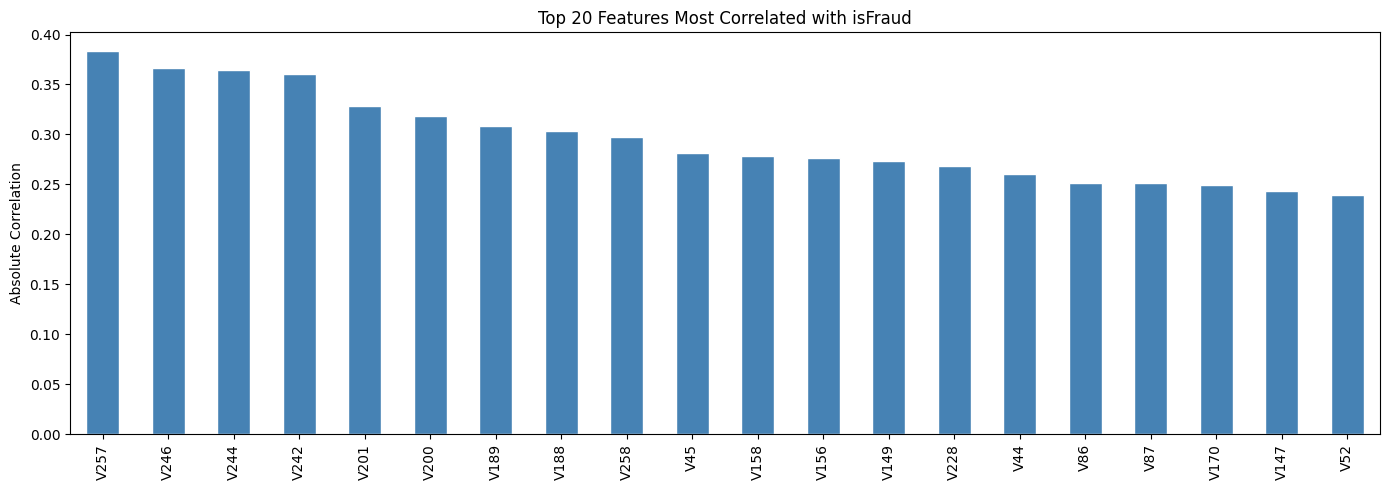

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64


In [9]:
correlations = train.select_dtypes(include=np.number).corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

correlations.head(20).plot(kind='bar', figsize=(14, 5), color='steelblue', edgecolor='white')
plt.title('Top 20 Features Most Correlated with isFraud')
plt.ylabel('Absolute Correlation')
plt.tight_layout()
plt.savefig('/kaggle/working/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(correlations.head(20))